In [23]:
from pathlib import Path
import numpy as np
from numpy.typing import NDArray
import matplotlib.pyplot as plt
import h5py

plt.style.use("paper.mplstyle")




Duplicate key in file 'paper.mplstyle', line 40 ('lines.linewidth     : 0.5')
Duplicate key in file 'paper.mplstyle', line 41 ('lines.markersize    : 4')
Bad value in file 'paper.mplstyle', line 17 ('font.size: 7,'): Key font.size: Could not convert '7,' to float
Bad value in file 'paper.mplstyle', line 18 ('axes.labelsize: 7,'): Key axes.labelsize: 7, is not a valid font size. Valid font sizes are xx-small, x-small, small, medium, large, x-large, xx-large, smaller, larger.
Bad value in file 'paper.mplstyle', line 19 ('xtick.labelsize: 6,'): Key xtick.labelsize: 6, is not a valid font size. Valid font sizes are xx-small, x-small, small, medium, large, x-large, xx-large, smaller, larger.
Bad value in file 'paper.mplstyle', line 20 ('ytick.labelsize: 6,'): Key ytick.labelsize: 6, is not a valid font size. Valid font sizes are xx-small, x-small, small, medium, large, x-large, xx-large, smaller, larger.
Bad value in file 'paper.mplstyle', line 21 ('legend.fontsize: 6,'): Key legend.fontsiz

In [24]:
current_dir = Path.cwd()/"other"/"data"
file_name1 = "lorentzian_echo0.001_10_us.npz"
file_name2 = "lorentzian_echo_10.0_us.hdf5"

print(current_dir)

def open_file_hd5(file_path: Path) -> NDArray:
    with h5py.File(file_path, 'r') as file:
        
        data_group = file['Data']
        data_dataset = data_group['Data']
        data = data_dataset[()]

        x = data.T[0][0][:]
        y = data[0][1][:]
        matrix = []
        for i in range(0, len(data.T)):
            matrix.append(data.T[i][2][:])

        data = [x, y, matrix]
        print(data[0])
        
    return data, None, None

    




data1 = np.load(current_dir/file_name1)
data2 = open_file_hd5(current_dir/file_name2)


x1, y1, z1 = data1["detunings"], data1["amplitudes"], data1["matrix"]
x2, y2, z2 = data2[0]




/Users/asafsolonnikov/Developer/amplitude-robust-spectroscopy/other/data
[-500000. -496016. -492032. -488048. -484064. -480080. -476096. -472112.
 -468128. -464144. -460160. -456176. -452192. -448208. -444224. -440240.
 -436256. -432272. -428288. -424304. -420320. -416336. -412352. -408368.
 -404384. -400400. -396416. -392432. -388448. -384464. -380480. -376496.
 -372512. -368528. -364544. -360560. -356576. -352592. -348608. -344624.
 -340640. -336656. -332672. -328688. -324704. -320720. -316736. -312752.
 -308768. -304784. -300800. -296816. -292832. -288848. -284864. -280880.
 -276896. -272912. -268928. -264944. -260960. -256976. -252992. -249008.
 -245024. -241040. -237056. -233072. -229088. -225104. -221120. -217136.
 -213152. -209168. -205184. -201200. -197216. -193232. -189248. -185264.
 -181280. -177296. -173312. -169328. -165344. -161360. -157376. -153392.
 -149408. -145424. -141440. -137456. -133472. -129488. -125504. -121520.
 -117536. -113552. -109568. -105584. -101600.  -976

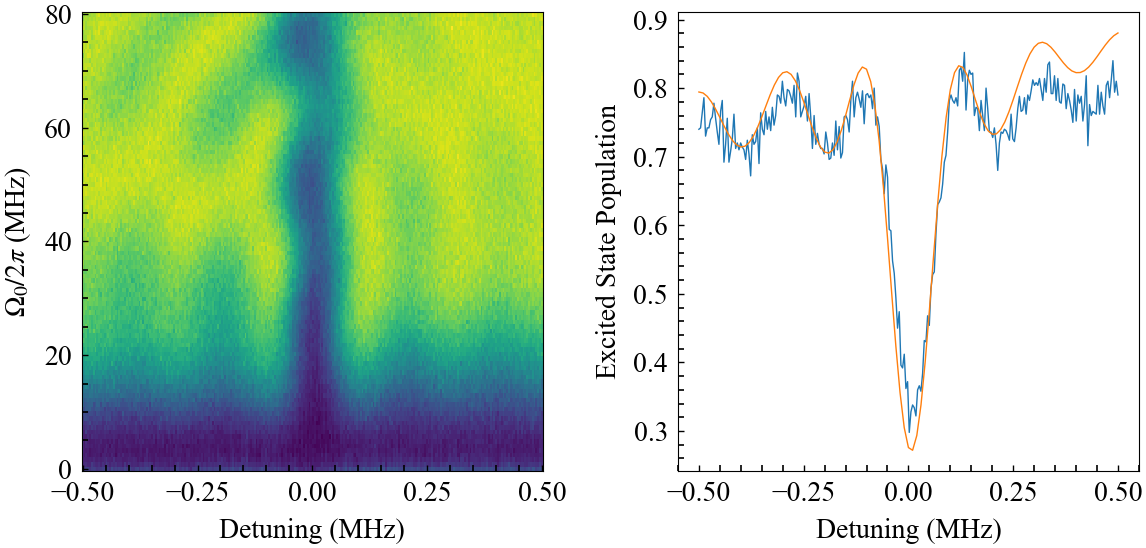

In [81]:

fig, axs = plt.subplots(1,2, figsize=(6,3))
axs[0].pcolormesh(x2/1e6, y2/np.pi*1.31, z2, shading="auto")
# axs[0].pcolormesh(x1, y1/2/np.pi/1e6, z1, shading="auto")

axs[0].set_xlabel("Detuning (MHz)")
axs[0].set_ylabel(r"$\Omega_{0}/2π$ (MHz)")
# axs[0].set_title("Final Z Expectation Value")

axs[1].plot(x2/1e6, z2[50])
axs[1].plot(x1/2/np.pi/1e6, z1[50], label="Lorentzian Echo")
axs[1].set_xlabel("Detuning (MHz)")
axs[1].set_ylabel("Excited State Population")
# axs[1].set_title("1D Spectrum at Zero Detuning")
# axs[0].colorbar(label="<Z>")
plt.tight_layout()
plt.savefig(current_dir/"comparison.png", dpi=300)